# Validation reward curves

This notebook reads TensorBoard logs and plots validation reward over training episodes for selected runs.

In [1]:
from pathlib import Path

import os
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator


REPO_FALLBACK = Path("/Users/zlr/Documents/CodingLab：DRL/CodingLab_DRL_team")

try:
    NOTEBOOK_DIR = Path.cwd().resolve()
except FileNotFoundError:
    # This can happen when a Jupyter kernel keeps a deleted or moved cwd.
    NOTEBOOK_DIR = REPO_FALLBACK / "statistic"
    os.chdir(REPO_FALLBACK)

PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "statistic" else NOTEBOOK_DIR
LOG_ROOT = PROJECT_ROOT / "logs2"
TAG = "Reward/validation"


def read_scalar_series(run_path: Path, tag: str = TAG, max_step: int | None = None):
    if not run_path.exists():
        raise FileNotFoundError(f"Missing TensorBoard log directory: {run_path}")

    event_files = list(run_path.glob("events.out.tfevents*"))
    if not event_files:
        raise FileNotFoundError(f"No TensorBoard event file found in: {run_path}")

    accumulator = EventAccumulator(str(run_path), size_guidance={"scalars": 0})
    accumulator.Reload()

    scalar_tags = accumulator.Tags().get("scalars", [])
    if tag not in scalar_tags:
        raise KeyError(f"Tag {tag!r} not found in {run_path}. Available scalar tags: {scalar_tags}")

    series = [(point.step, point.value) for point in accumulator.Scalars(tag)]
    if max_step is not None:
        series = [(step, value) for step, value in series if step <= max_step]

    if not series:
        raise ValueError(f"No scalar points left after filtering {tag!r} to step <= {max_step}")

    return series


def load_curves(runs, tag: str = TAG, total_episodes: int | None = None):
    curves = []
    missing_runs = []

    for run in runs:
        try:
            series = read_scalar_series(run["path"], tag=tag, max_step=total_episodes)
        except Exception as exc:
            missing_runs.append((run["name"], run["path"], exc))
            continue

        best_step, best_value = max(series, key=lambda item: item[1])
        curves.append({**run, "series": series, "best_step": best_step, "best_value": best_value})

    return curves, missing_runs


def print_curve_summary(curves, missing_runs):
    for curve in curves:
        print(
            f"{curve['name']}: {len(curve['series'])} points, "
            f"best validation reward = {curve['best_value']:.3f} at episode {curve['best_step']}"
        )

    if missing_runs:
        print("\nRuns not plotted:")
        for name, path, exc in missing_runs:
            print(f"- {name}: {path} ({exc})")


def plot_validation_curves(
    curves,
    variant: int,
    total_episodes: int,
    axis_width: float = 8.0,
    right_panel_width: float = 5.0,
    left_margin_width: float = 1.25,
    panel_gap_width: float = 0.25,
    height: float = 5.6,
):
    if not curves:
        raise RuntimeError("No curves were loaded. Check RUNS and LOG_ROOT above.")

    fig_width = left_margin_width + axis_width + panel_gap_width + right_panel_width
    fig = plt.figure(figsize=(fig_width, height), dpi=140)

    bottom_margin = 0.72
    top_margin = 0.22
    plot_height = height - bottom_margin - top_margin

    ax = fig.add_axes([
        left_margin_width / fig_width,
        bottom_margin / height,
        axis_width / fig_width,
        plot_height / height,
    ])
    legend_ax = fig.add_axes([
        (left_margin_width + axis_width + panel_gap_width) / fig_width,
        bottom_margin / height,
        right_panel_width / fig_width,
        plot_height / height,
    ])
    legend_ax.axis("off")

    for idx, curve in enumerate(curves):
        steps = [step for step, _ in curve["series"]]
        rewards = [value for _, value in curve["series"]]
        ax.plot(steps, rewards, label=curve["name"], color=curve["color"], linewidth=2.2)
        ax.scatter(
            [curve["best_step"]],
            [curve["best_value"]],
            color=curve["color"],
            edgecolor="white",
            linewidth=1.2,
            s=70,
            zorder=5,
        )
        ax.vlines(
            curve["best_step"],
            ymin=0,
            ymax=curve["best_value"],
            color=curve["color"],
            linestyle="--",
            linewidth=1.1,
            alpha=0.75,
        )
        ax.hlines(
            curve["best_value"],
            xmin=0,
            xmax=curve["best_step"],
            color=curve["color"],
            linestyle="--",
            linewidth=1.1,
            alpha=0.75,
        )
        ax.annotate(
            f"{curve['best_value']:.2f}",
            xy=(0, curve["best_value"]),
            xytext=(-10, 5 if idx % 2 == 0 else -5),
            textcoords="offset points",
            ha="right",
            va="bottom" if idx % 2 == 0 else "top",
            color=curve["color"],
            fontsize=9,
            fontweight="bold",
            annotation_clip=False,
        )
        ax.annotate(
            f"{curve['best_step']}",
            xy=(curve["best_step"], 0),
            xytext=(0, -28),
            textcoords="offset points",
            ha="center",
            va="top",
            color=curve["color"],
            fontsize=8,
            fontweight="bold",
            annotation_clip=False,
        )

    legend_x = 0.03
    legend_y = 0.98
    line_width = 0.09
    text_gap = 0.035
    line_gap = 0.070
    row_gap = 0.018
    legend_width = 0.88

    row_heights = [line_gap * max(1, len(curve["name"].splitlines())) for curve in curves]
    legend_height = sum(row_heights) + row_gap * (len(curves) - 1) + 0.055
    legend_box = FancyBboxPatch(
        (0.0, legend_y - legend_height + 0.02),
        legend_width,
        legend_height,
        boxstyle="round,pad=0.012",
        facecolor="white",
        edgecolor="0.8",
        transform=legend_ax.transAxes,
        clip_on=False,
        zorder=10,
    )
    legend_ax.add_patch(legend_box)

    current_y = legend_y - 0.035
    for curve in curves:
        label_lines = curve["name"].splitlines()
        legend_ax.plot(
            [legend_x, legend_x + line_width],
            [current_y, current_y],
            transform=legend_ax.transAxes,
            color=curve["color"],
            linewidth=2.8,
            clip_on=False,
            zorder=11,
        )
        legend_ax.text(
            legend_x + line_width + text_gap,
            current_y,
            label_lines[0],
            transform=legend_ax.transAxes,
            ha="left",
            va="center",
            fontsize=10,
            zorder=11,
        )
        for line_idx, label_line in enumerate(label_lines[1:], start=1):
            legend_ax.text(
                legend_x + line_width + text_gap,
                current_y - line_gap * line_idx,
                label_line,
                transform=legend_ax.transAxes,
                ha="left",
                va="center",
                fontsize=10,
                zorder=11,
            )
        current_y -= line_gap * max(1, len(label_lines)) + row_gap

    info_y = legend_y - legend_height - 0.045
    info_lines = [
        f"Variant: {variant}",
        f"Total Episodes: {total_episodes // 1000}k",
        "DRL Policy: Rainbow DQN",
    ]
    for line_idx, info_line in enumerate(info_lines):
        legend_ax.text(
            legend_x,
            info_y - 0.085 * line_idx,
            info_line,
            transform=legend_ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
        )

    ax.set_xlabel("Training Episode", labelpad=10)
    ax.set_ylabel("Average Validation Reward", labelpad=12)
    ax.set_xlim(0, total_episodes)
    ax.set_ylim(bottom=0)
    ax.set_xticks(range(0, total_episodes + 1, 1000))
    ax.grid(axis="x", linestyle="--", alpha=0.28)
    ax.grid(axis="y", linestyle="-", alpha=0.18)

    return fig, ax


print(f"Project root: {PROJECT_ROOT}")
print(f"Log root: {LOG_ROOT}")


Project root: /Users/zlr/Documents/CodingLab：DRL/CodingLab_DRL_team
Log root: /Users/zlr/Documents/CodingLab：DRL/CodingLab_DRL_team/logs2


2026-07-15 11:52:34.507721: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Training Results with Item Value Channel: 100 points, best validation reward = 222.405 at episode 10000
Training Results with Item Value Channel
(Simple Version): 100 points, best validation reward = 221.545 at episode 7200
w/o Item Value: 100 points, best validation reward = 219.555 at episode 9400


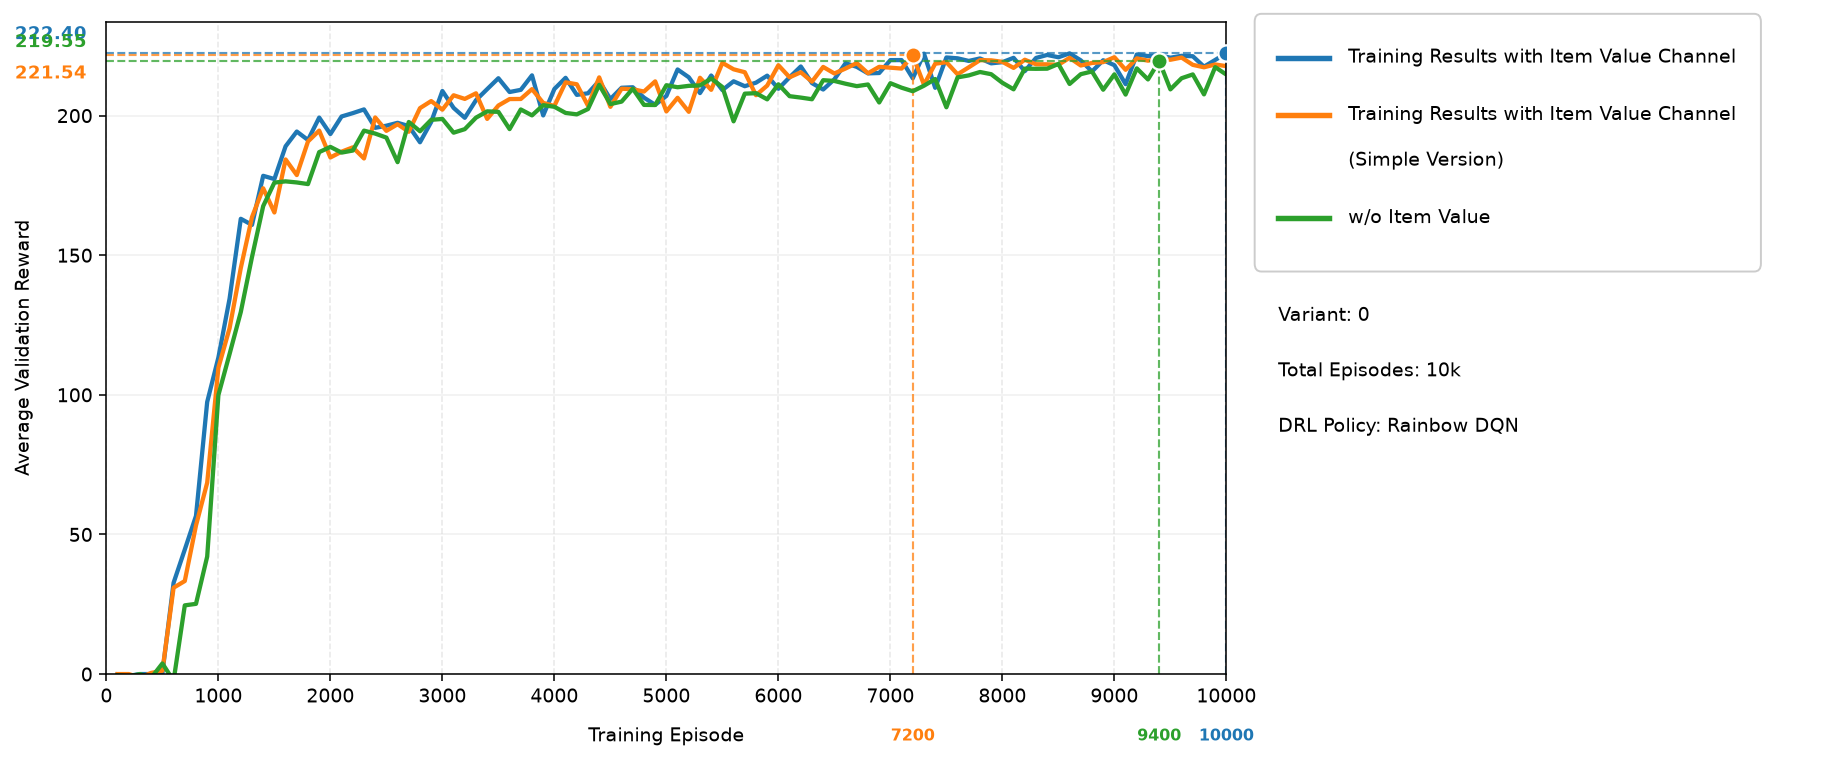

In [2]:
VARIANT = 0
TOTAL_EPISODES = 10_000

RUNS = [
    {
        "name": "Training Results with Item Value Channel",
        "path": LOG_ROOT / "DQN_v8.11.26_variant_0",
        "color": "tab:blue",
    },
    {
        "name": "Training Results with Item Value Channel\n(Simple Version)",
        "path": LOG_ROOT / "DQN_v8.12.0_variant_0",
        "color": "tab:orange",
    },
    {
        "name": "w/o Item Value",
        "path": LOG_ROOT / "DQN_v8.9.2_variant_0",
        "color": "tab:green",
    },
]

curves, missing_runs = load_curves(RUNS, total_episodes=TOTAL_EPISODES)
print_curve_summary(curves, missing_runs)
fig, ax = plot_validation_curves(
    curves,
    variant=VARIANT,
    total_episodes=TOTAL_EPISODES,
    axis_width=8.0,
    right_panel_width=4.0,
)
plt.show()

DQN v8.9.2 (w/o Item Value): 100 points, best validation reward = 219.555 at episode 9400
DQN v8.5.28: 100 points, best validation reward = 219.490 at episode 8600


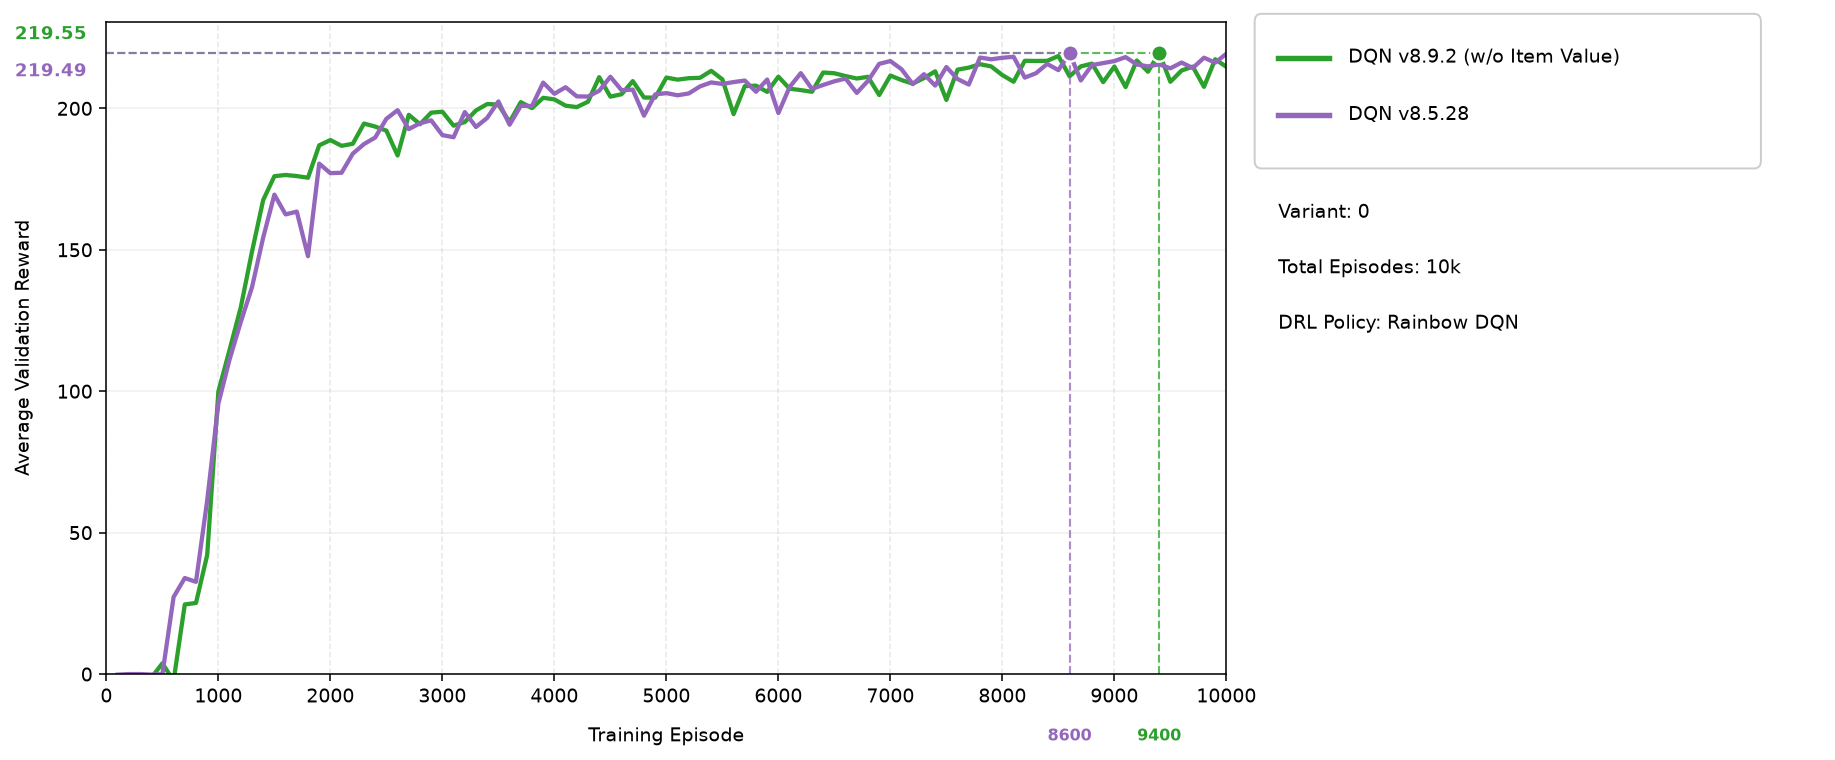

In [3]:
COMPARISON_RUNS = [
    {
        "name": "DQN v8.9.2 (w/o Item Value)",
        "path": LOG_ROOT / "DQN_v8.9.2_variant_0",
        "color": "tab:green",
    },
    {
        "name": "DQN v8.5.28",
        "path": LOG_ROOT / "DQN_v8.5.28_variant_0",
        "color": "tab:purple",
    },
]

comparison_curves, comparison_missing_runs = load_curves(
    COMPARISON_RUNS,
    total_episodes=TOTAL_EPISODES,
)
print_curve_summary(comparison_curves, comparison_missing_runs)
comparison_fig, comparison_ax = plot_validation_curves(
    comparison_curves,
    variant=VARIANT,
    total_episodes=TOTAL_EPISODES,
    axis_width=8.0,
    right_panel_width=4.0,
)
plt.show()